In [145]:
import numpy as np
import pynbody
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import tangos
import h5py

In [146]:
simpath = '/data/REPOSITORY/romulus_zooms'
os.environ['TANGOS_SIMULATION_FOLDER'] = simpath
# os.environ['TANGOS_DB_CONNECTION'] = simpath + 'rom25_dwarf_zooms.db'
tangos.core.init_db(simpath + '/rom25_dwarf_zooms.db')
#tangos.all_simulations()

simroot = 'r431' 
simname = simroot + '.romulus25.3072g1HsbBH'
timestep = '004096' #'000864' #'000960' #'004096'

In [147]:
# Read in the simulation in pynbody
print('Loading simulation ', simname, ' at timestep ', timestep)
s = pynbody.load(simpath + '/' + simname + '/' + simname + '.' + timestep + '/' + simname + '.' + timestep)
s.halos(priority=['AHFCatalogue'])
h = s.halos(halo_numbers='v1')
s.physical_units()
snaptime = s.properties['time'].in_units('Gyr')

Loading simulation  r431.romulus25.3072g1HsbBH  at timestep  004096


In [148]:
# Read in the unique halo ids assigned for all star particles from Anna's database
sh_path = '/home/awright/dwarf_stellar_halos/'
write_path = '/home/christenc/Code/Datafiles/stellar_halos/'

with h5py.File(sh_path+'/'+simroot+'/'+simroot+'_allhalostardata.h5','r') as f:
    hostids = f['host_IDs'].asstr()[:] # unique host IDs
    partids = f['particle_IDs'][:] # iords
    pct = f['particle_creation_times'][:] # formation times
    ph = f['particle_hosts'][:] # local host IDs (i.e., host at formation time)
    pp = f['particle_positions'][:] # position at formation time
    tsloc = f['timestep_location'][:] # snapshot where star particle first appears
uIDs = np.unique(hostids)

In [149]:
# Find the appropriate timestep in the tangos database

sim = tangos.get_simulation(simname)
# Determine the main progenitor of the main halo
mh_prog,mh_dbid, ts = sim[-1][1].calculate_for_progenitors('halo_number()','dbid()','t()')
mh_halos = [tangos.get_halo(dbid) for dbid in mh_dbid]
ts_mask = np.isclose(ts, snaptime, atol=1e-2)
timestep_t = tangos.get_simulation(f"{simname}").timesteps[::-1][np.nonzero(ts_mask)[0][0]]
print(timestep_t)

<TimeStep 'r431.romulus25.3072g1HsbBH/r431.romulus25.3072g1HsbBH.004096/r431.romulus25.3072g1HsbBH.004096' z=-0.00 t=13.80 Gyr>


In [150]:
# Center on the appropriate halo

try:
    haloid = mh_prog[np.nonzero(ts_mask)[0][0]] #0 #1010110
    halo = h[haloid]
    pynbody.analysis.center(halo)
except:
    print("Can't read in halo", haloid)
    extent = float(s.properties['boxsize'])/s.properties['a'] # size of box in comoving kpc
    halo_t = timestep_t.halos[mh_prog[np.nonzero(ts_mask)[0][0]]]
    xcen = (halo_t['Xc']*1000/s.properties['h'] - extent/2)*s.properties['a']
    ycen = (halo_t['Yc']*1000/s.properties['h'] - extent/2)*s.properties['a']
    zcen = (halo_t['Zc']*1000/s.properties['h'] - extent/2)*s.properties['a']
    #center = [xcen, ycen, zcen]
    center = [-360, -120, -725]
    tx = pynbody.transformation.inverse_translate(s, center)
    # Filter in the surrounding area
    size = 100  # kpc
    halo = s
    #halo = s[pynbody.filt.Sphere(str(size)+' kpc', (0,0,0))]

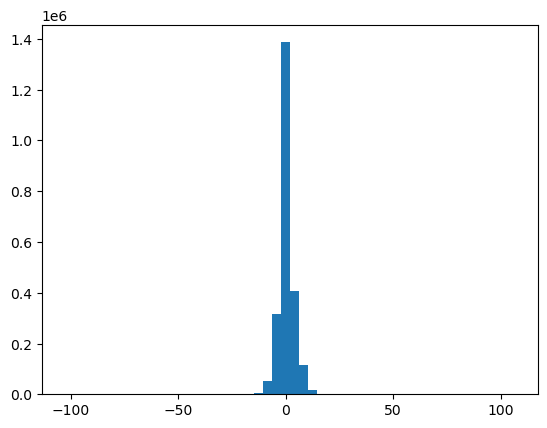

In [151]:
plt.hist(halo.star['z'].in_units('kpc'), bins=50, label='All Stars')
plt.show()

In [152]:
# Filter for the star particles in the simulation that are not in Anna's code
try:
    iords=s.s['iord']
except:
    iords=np.arange(len(s.star))+30558121 # First iord -1
mask = s.s['tform'] > 0
mask2 = np.isin(iords, partids)
missing_stars = s.star[mask & ~mask2]

mask3 = np.isin(iords, np.array([30944578, 30944579, 30944580, 30944581]))
missing_stars = s.star[mask3]

print('Total Missing Star Particles: ',len(missing_stars))
try:
    print('Iord: ',missing_stars['iord' ])
except:
    #pass
    print('Iord: ',iords[mask & ~mask2]) # [30559428 30559443 30578583 30583667 30586258 30586532 30600854 30944578 30944579 30944580 30944581]
#print('Iord: ',iords[mask & ~mask2])   
print('Formation Time: ',missing_stars['tform'].in_units('Gyr'))
print('Timestep: ',missing_stars['tform'].in_units('Gyr')/13.8*4096)

Total Missing Star Particles:  4
Iord:  [30944578 30944579 30944580 30944581]
Formation Time:  [2.62526745 2.62526745 2.62526745 2.62526745]
Timestep:  [779.20981833 779.20981833 779.20981833 779.20981833]


In [153]:
center = [np.mean(missing_stars['x'].in_units('kpc')), np.mean(missing_stars['y'].in_units('kpc')), np.mean(missing_stars['z'].in_units('kpc'))]
tx = pynbody.transformation.inverse_translate(s, center)

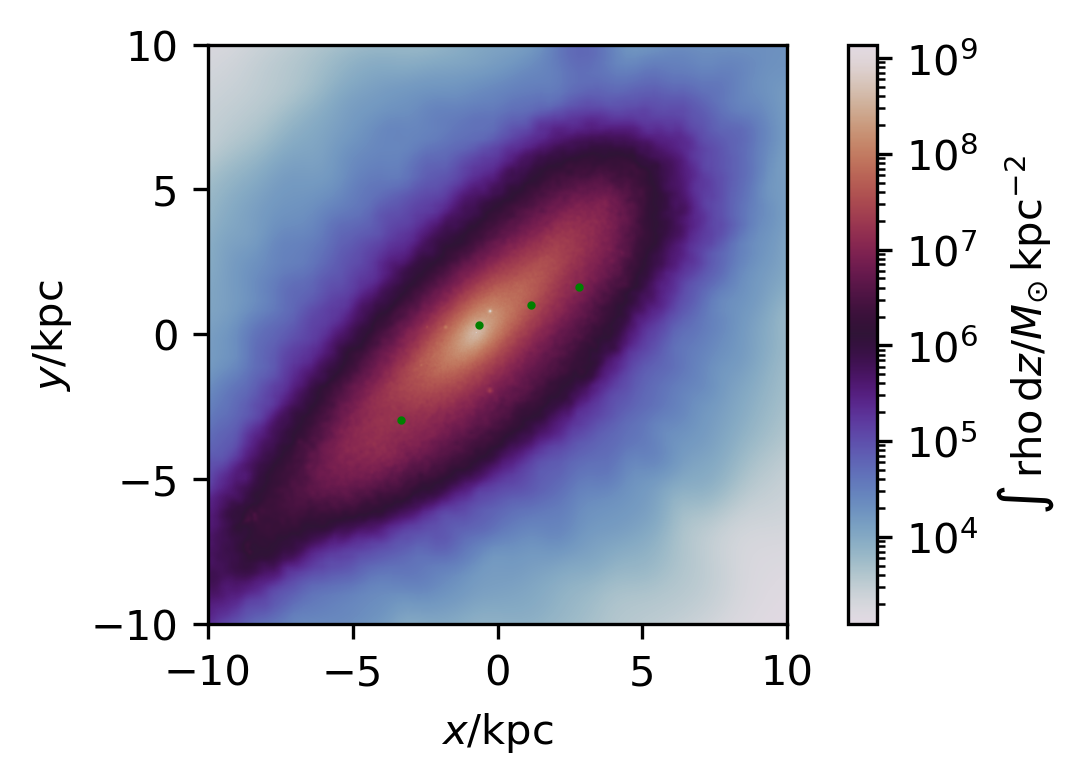

In [154]:
fig, ax = plt.subplots(1,1,dpi=300, figsize=(3.5,2.5), constrained_layout=True)
width = 20
pynbody.plot.image(halo.star, width=f"{width} kpc", axes= ax,units="Msol kpc^-2", cmap="twilight", log=True)

for i in range(len(missing_stars)): #[0:100]
    #print(missing_stars[i])#.in_units('kpc'))
    star = missing_stars[i]
    ax.plot(star['x'].in_units('kpc')[0], star['y'].in_units('kpc')[0], marker='o', color='green', markersize=1)

plt.show()

In [155]:
len(halo.star), len(s.s.star)

(2299655, 2300806)